# Week 8 — Deep Learning & Neural Networks
## Task 13: Deep Learning Fundamentals, CNNs, Transfer Learning & MNIST Assignment

**Topics covered:**
- Introduction to Deep Learning & Neural Networks
- Backpropagation from Scratch
- ANN from Scratch
- Computer Vision & CNNs
- Transfer Learning
- **Assignment: MNIST Handwritten Digit Recognition**


## 1. Introduction to Deep Learning

**What is Deep Learning?**

Deep Learning is a subset of Machine Learning that uses **artificial neural networks** with multiple layers (hence "deep") to learn representations of data. It excels at:
- Image recognition & computer vision
- Natural language processing
- Speech recognition
- Game playing & robotics

**Biological vs Artificial Neurons**

| Biological Neuron | Artificial Neuron |
|---|---|
| Dendrites receive signals | Inputs (features) |
| Cell body processes signals | Weighted sum + bias |
| Axon transmits output | Activation function output |
| Synapses connect neurons | Weights (parameters) |

**Key Concepts:**
- **Neuron**: Basic computational unit that takes inputs, applies weights, adds bias, and passes through an activation function
- **Layer**: Collection of neurons operating in parallel
- **Deep Network**: Network with multiple hidden layers between input and output


## 2. The Perceptron — Simplest Neural Network

The **perceptron** is the simplest form of a neural network — a single neuron that can learn linearly separable functions.

$$y = f\left(\sum_{i=1}^{n} w_i x_i + b\right)$$

where $f$ is a step function.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Perceptron Implementation ──
class Perceptron:
    def __init__(self, n_inputs, lr=0.1, epochs=100):
        self.weights = np.zeros(n_inputs)
        self.bias = 0
        self.lr = lr
        self.epochs = epochs

    def step(self, x):
        return 1 if x >= 0 else 0

    def predict(self, x):
        return self.step(np.dot(self.weights, x) + self.bias)

    def fit(self, X, y):
        for _ in range(self.epochs):
            for xi, yi in zip(X, y):
                pred = self.predict(xi)
                error = yi - pred
                self.weights += self.lr * error * xi
                self.bias += self.lr * error

# AND Gate
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y_and = np.array([0,0,0,1])
y_or  = np.array([0,1,1,1])

p_and = Perceptron(2)
p_and.fit(X, y_and)

p_or = Perceptron(2)
p_or.fit(X, y_or)

print("AND Gate Predictions:")
for xi in X:
    print(f"  {xi} -> {p_and.predict(xi)}")

print("\nOR Gate Predictions:")
for xi in X:
    print(f"  {xi} -> {p_or.predict(xi)}")


AND Gate Predictions:
  [0 0] -> 0
  [0 1] -> 0
  [1 0] -> 0
  [1 1] -> 1

OR Gate Predictions:
  [0 0] -> 0
  [0 1] -> 1
  [1 0] -> 1
  [1 1] -> 1


## 3. Neural Network Fundamentals

### Activation Functions

| Function | Formula | Range | Use Case |
|----------|---------|-------|----------|
| **Sigmoid** | $\sigma(x) = \frac{1}{1+e^{-x}}$ | (0, 1) | Binary classification output |
| **ReLU** | $f(x) = \max(0, x)$ | [0, ∞) | Hidden layers (most common) |
| **Tanh** | $\tanh(x)$ | (-1, 1) | Hidden layers |
| **Softmax** | $\frac{e^{x_i}}{\sum e^{x_j}}$ | (0, 1) | Multi-class output |

### Loss Functions
- **MSE**: Regression tasks
- **Binary Cross-Entropy**: Binary classification
- **Categorical Cross-Entropy**: Multi-class classification


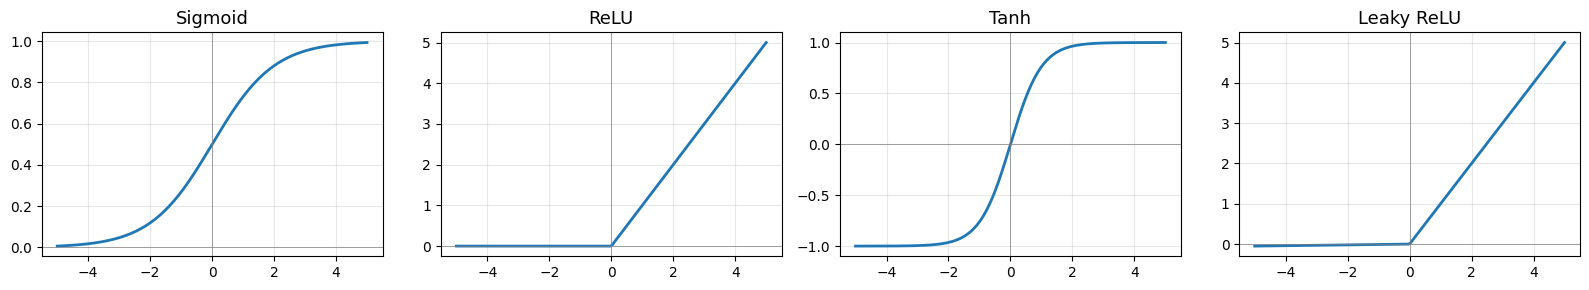

In [2]:
# Visualize Activation Functions
def sigmoid(x):   return 1 / (1 + np.exp(-x))
def relu(x):      return np.maximum(0, x)
def tanh(x):      return np.tanh(x)
def leaky_relu(x, alpha=0.01): return np.where(x > 0, x, alpha * x)

x = np.linspace(-5, 5, 200)

fig, axes = plt.subplots(1, 4, figsize=(16, 3))
funcs = [(sigmoid, 'Sigmoid'), (relu, 'ReLU'), (tanh, 'Tanh'), (leaky_relu, 'Leaky ReLU')]
for ax, (fn, name) in zip(axes, funcs):
    ax.plot(x, fn(x), linewidth=2)
    ax.set_title(name, fontsize=13)
    ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
    ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Backpropagation from Scratch

Backpropagation computes the gradient of the loss with respect to each weight by applying the **chain rule** layer-by-layer from output back to input.

**Steps:**
1. **Forward Pass** — compute predictions
2. **Compute Loss** — compare predictions to targets
3. **Backward Pass** — compute gradients via chain rule
4. **Update Weights** — gradient descent step


Epoch     0  Loss: 0.255675
Epoch  2000  Loss: 0.249659
Epoch  4000  Loss: 0.202610
Epoch  6000  Loss: 0.022670
Epoch  8000  Loss: 0.005194

Final predictions (XOR):
  [0 0] -> 0.0562
  [0 1] -> 0.9507
  [1 0] -> 0.9506
  [1 1] -> 0.0512


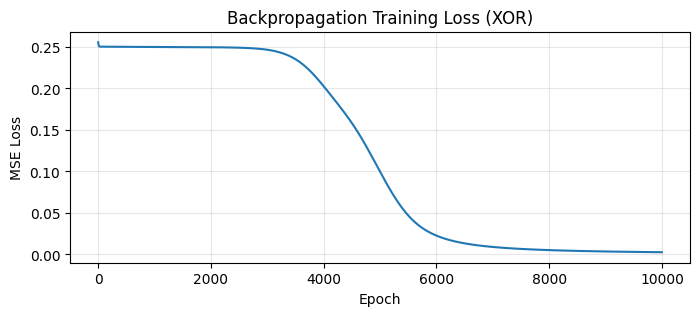

In [3]:
# ── Backpropagation from Scratch (2-layer NN on a toy dataset) ──
np.random.seed(42)

# Toy dataset: XOR (not linearly separable)
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([[0],[1],[1],[0]])

# Network: 2 -> 4 -> 1
input_size, hidden_size, output_size = 2, 4, 1
lr = 0.5
epochs = 10000

# Initialize weights
W1 = np.random.randn(input_size, hidden_size) * 0.5
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.5
b2 = np.zeros((1, output_size))

def sigmoid(x):   return 1 / (1 + np.exp(-x))
def sigmoid_d(x): return x * (1 - x)

losses = []
for epoch in range(epochs):
    # Forward pass
    z1 = X @ W1 + b1
    a1 = sigmoid(z1)
    z2 = a1 @ W2 + b2
    a2 = sigmoid(z2)

    # Loss (MSE)
    loss = np.mean((y - a2) ** 2)
    losses.append(loss)

    # Backward pass
    dL_da2 = -(y - a2)                     # dL/da2
    da2_dz2 = sigmoid_d(a2)                # da2/dz2
    delta2 = dL_da2 * da2_dz2              # dL/dz2

    dL_da1 = delta2 @ W2.T                 # dL/da1
    da1_dz1 = sigmoid_d(a1)                # da1/dz1
    delta1 = dL_da1 * da1_dz1              # dL/dz1

    # Update weights
    W2 -= lr * (a1.T @ delta2) / len(X)
    b2 -= lr * np.mean(delta2, axis=0, keepdims=True)
    W1 -= lr * (X.T @ delta1) / len(X)
    b1 -= lr * np.mean(delta1, axis=0, keepdims=True)

    if epoch % 2000 == 0:
        print(f"Epoch {epoch:5d}  Loss: {loss:.6f}")

print(f"\nFinal predictions (XOR):")
for xi, pred in zip(X, a2):
    print(f"  {xi} -> {pred[0]:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Backpropagation Training Loss (XOR)")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss"); plt.grid(alpha=0.3)
plt.show()


## 5. Feedforward ANN from Scratch (NumPy Only)

A reusable multi-layer neural network built entirely with NumPy.


Training ANN from scratch on XOR:
  Epoch     0  Loss: 0.273318
  Epoch  1000  Loss: 0.126018
  Epoch  2000  Loss: 0.009131
  Epoch  3000  Loss: 0.003102
  Epoch  4000  Loss: 0.001722

Predictions: [0 1 1 0]
Expected:    [0, 1, 1, 0]


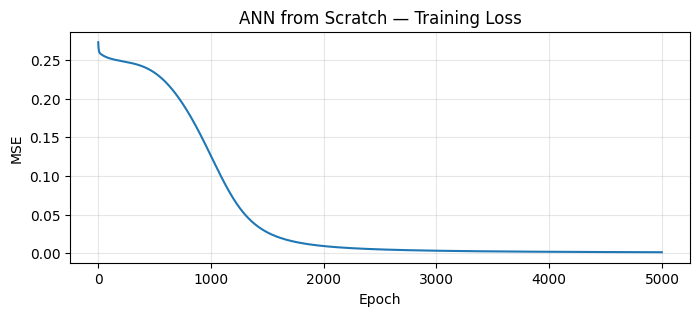

In [4]:
class NeuralNetwork:
    """Simple feedforward neural network from scratch."""
    def __init__(self, layers, lr=0.01):
        self.lr = lr
        self.weights = []
        self.biases = []
        for i in range(len(layers) - 1):
            w = np.random.randn(layers[i], layers[i+1]) * np.sqrt(2.0 / layers[i])
            b = np.zeros((1, layers[i+1]))
            self.weights.append(w)
            self.biases.append(b)

    def _sigmoid(self, x):   return 1 / (1 + np.exp(-np.clip(x, -500, 500)))
    def _sigmoid_d(self, x): return x * (1 - x)

    def forward(self, X):
        self.activations = [X]
        for w, b in zip(self.weights, self.biases):
            z = self.activations[-1] @ w + b
            a = self._sigmoid(z)
            self.activations.append(a)
        return self.activations[-1]

    def backward(self, y):
        m = y.shape[0]
        delta = (self.activations[-1] - y) * self._sigmoid_d(self.activations[-1])
        for i in reversed(range(len(self.weights))):
            dw = self.activations[i].T @ delta / m
            db = np.mean(delta, axis=0, keepdims=True)
            if i > 0:
                delta = (delta @ self.weights[i].T) * self._sigmoid_d(self.activations[i])
            self.weights[i] -= self.lr * dw
            self.biases[i]  -= self.lr * db

    def fit(self, X, y, epochs=5000, verbose=True):
        losses = []
        for e in range(epochs):
            pred = self.forward(X)
            loss = np.mean((y - pred) ** 2)
            losses.append(loss)
            self.backward(y)
            if verbose and e % 1000 == 0:
                print(f"  Epoch {e:5d}  Loss: {loss:.6f}")
        return losses

    def predict(self, X):
        return (self.forward(X) > 0.5).astype(int)

# Demo: XOR
print("Training ANN from scratch on XOR:")
nn = NeuralNetwork([2, 8, 1], lr=1.0)
losses = nn.fit(X, y, epochs=5000)
print(f"\nPredictions: {nn.predict(X).flatten()}")
print(f"Expected:    [0, 1, 1, 0]")

plt.figure(figsize=(8, 3))
plt.plot(losses); plt.title("ANN from Scratch — Training Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.grid(alpha=0.3); plt.show()


## 6. Data Preprocessing & Feature Engineering with Neural Networks

Key preprocessing steps for neural networks:
- **Normalization / Standardization** — scale features to similar ranges (speeds convergence)
- **One-Hot Encoding** — convert categorical labels to vectors
- **Reshaping** — flatten images or reshape for CNNs
- **Train/Test Split** — avoid overfitting evaluation


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step
Training set shape : (60000, 28, 28)  Labels: (60000,)
Test set shape     : (10000, 28, 28)  Labels: (10000,)
Pixel value range  : [0, 255]

After split — Train: (54000, 28, 28), Val: (6000, 28, 28), Test: (10000, 28, 28)
Normalized pixel range: [0.0, 1.0]


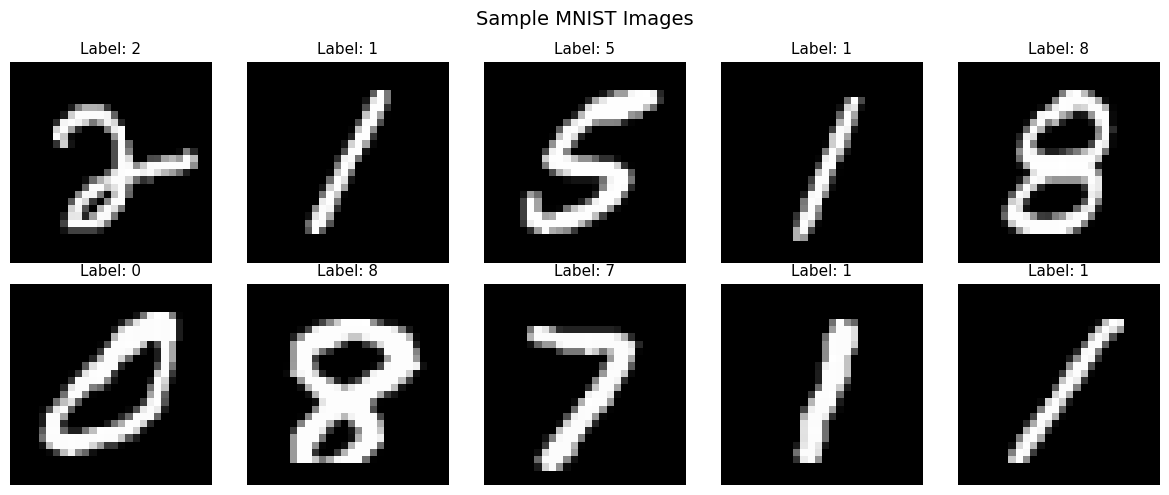


One-hot example — label 2: [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Load MNIST to demonstrate preprocessing
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Training set shape : {X_train_full.shape}  Labels: {y_train_full.shape}")
print(f"Test set shape     : {X_test.shape}  Labels: {y_test.shape}")
print(f"Pixel value range  : [{X_train_full.min()}, {X_train_full.max()}]")

# Normalize to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test       = X_test.astype('float32') / 255.0

# Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.1, random_state=42, stratify=y_train_full
)
print(f"\nAfter split — Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Normalized pixel range: [{X_train.min()}, {X_train.max()}]")

# Visualize some samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}", fontsize=11)
    ax.axis('off')
plt.suptitle("Sample MNIST Images", fontsize=14)
plt.tight_layout(); plt.show()

# One-hot encode labels
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_val_cat   = keras.utils.to_categorical(y_val, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)
print(f"\nOne-hot example — label {y_train[0]}: {y_train_cat[0]}")


## 7. Computer Vision — Convolutional Neural Networks (CNNs)

### Key Components

| Layer | Purpose |
|-------|---------|
| **Conv2D** | Learns spatial features (edges, textures, shapes) using learnable filters |
| **MaxPooling2D** | Down-samples feature maps, reduces computation, adds translation invariance |
| **Flatten** | Converts 2D feature maps into 1D vector for dense layers |
| **Dense** | Fully-connected layer for classification |
| **Dropout** | Regularization — randomly disables neurons during training |

### How Convolution Works
A small filter (kernel) slides over the image, computing element-wise multiplication and summation to produce a feature map. Deeper layers capture increasingly abstract features:
- Layer 1: edges, gradients
- Layer 2: textures, patterns
- Layer 3+: object parts, shapes


## 8. Image Preprocessing & Augmentation

Data augmentation artificially expands the training set by applying random transformations, helping the model generalize better.


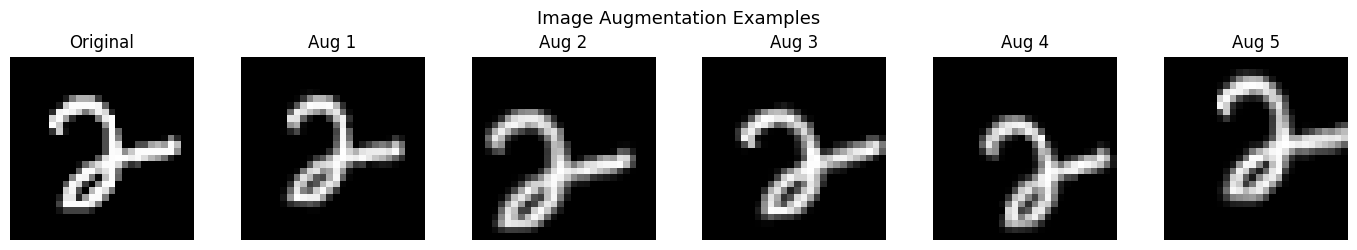

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define augmentation pipeline
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    shear_range=5,
)

# Show augmented versions of a single image
sample_img = X_train[0].reshape(1, 28, 28, 1)
fig, axes = plt.subplots(1, 6, figsize=(14, 2.5))
axes[0].imshow(X_train[0], cmap='gray'); axes[0].set_title("Original"); axes[0].axis('off')
for i, batch in enumerate(datagen.flow(sample_img, batch_size=1)):
    axes[i+1].imshow(batch[0].reshape(28, 28), cmap='gray')
    axes[i+1].set_title(f"Aug {i+1}"); axes[i+1].axis('off')
    if i == 4: break
plt.suptitle("Image Augmentation Examples", fontsize=13)
plt.tight_layout(); plt.show()


## 9. Pretrained CNN Architectures & Transfer Learning

**Transfer Learning** uses a model pre-trained on a large dataset (e.g. ImageNet) as a starting point, then fine-tunes it on a new task. This:
- Reduces training time dramatically
- Works well even with small datasets
- Leverages learned feature representations

**Popular Architectures:** VGG16, ResNet50, MobileNetV2, InceptionV3, EfficientNet


In [7]:
# Load pretrained MobileNetV2 and classify a sample image
base_model = keras.applications.MobileNetV2(weights='imagenet', include_top=True)
print(f"MobileNetV2 — Total layers: {len(base_model.layers)}")
print(f"Input shape: {base_model.input_shape}")
print(f"Output shape: {base_model.output_shape}")


14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step
MobileNetV2 — Total layers: 156
Input shape: (None, 224, 224, 3)
Output shape: (None, 1000)


In [8]:
# Transfer Learning demo: feature extraction with MobileNetV2
# Build a small classifier on top of frozen MobileNetV2 features
base = keras.applications.MobileNetV2(
    weights='imagenet', include_top=False,
    input_shape=(96, 96, 3)
)
base.trainable = False  # Freeze base model

transfer_model = keras.Sequential([
    base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

transfer_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
transfer_model.summary()
print("\n✅ Transfer learning model ready (base frozen, classifier trainable)")
print("In practice, you would fine-tune this on your custom dataset.")


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


✅ Transfer learning model ready (base frozen, classifier trainable)
In practice, you would fine-tune this on your custom dataset.


---
# Assignment: Handwritten Digit Recognition (MNIST)
## Building ANN & CNN with Keras/TensorFlow for Image Classification
---


### Part A — ANN (Dense / Fully Connected Network)


In [9]:
# ── Build ANN for MNIST ──
from tensorflow.keras.callbacks import EarlyStopping

# Flatten images for ANN: (28, 28) -> (784,)
X_train_flat = X_train.reshape(-1, 784)
X_val_flat   = X_val.reshape(-1, 784)
X_test_flat  = X_test.reshape(-1, 784)

ann_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
], name="MNIST_ANN")

ann_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()


Model: "MNIST_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 570,506 (2.18 MB)

 Trainable params: 568,970 (2.17 MB)

 Non-trainable params: 1,536 (6.00 KB)

In [10]:
# Train the ANN
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

ann_history = ann_model.fit(
    X_train_flat, y_train_cat,
    validation_data=(X_val_flat, y_val_cat),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - accuracy: 0.9021 - loss: 0.3166 - val_accuracy: 0.9548 - val_loss: 0.1425
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 41ms/step - accuracy: 0.9545 - loss: 0.1518 - val_accuracy: 0.9717 - val_loss: 0.1015
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.9638 - loss: 0.1178 - val_accuracy: 0.9700 - val_loss: 0.0963
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9697 - loss: 0.0958 - val_accuracy: 0.9740 - val_loss: 0.0904
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 22s 41ms/step - accuracy: 0.9740 - loss: 0.0832 - val_accuracy: 0.9777 - val_loss: 0.0817
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 39ms/step - accuracy: 0.9760 - loss: 0.0764 - val_accuracy: 0.9767 - val_loss: 0.0832
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9775 - loss: 0.0698 - val_accuracy: 0.9792 - val_loss: 0.0829
Epoch 8/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9800 - loss: 0.0623 - 

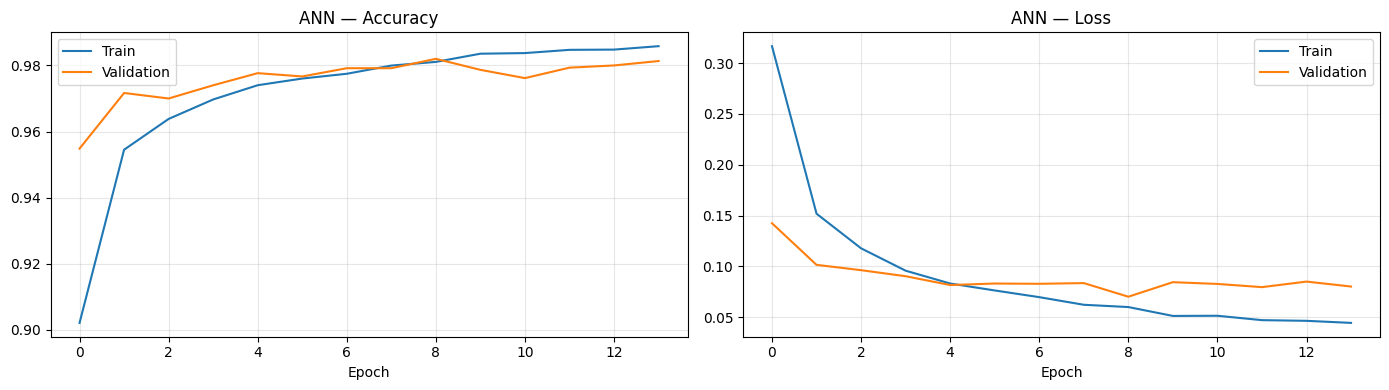

In [11]:
# ANN Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(ann_history.history['accuracy'], label='Train')
ax1.plot(ann_history.history['val_accuracy'], label='Validation')
ax1.set_title('ANN — Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(ann_history.history['loss'], label='Train')
ax2.plot(ann_history.history['val_loss'], label='Validation')
ax2.set_title('ANN — Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


In [12]:
# Evaluate ANN on test set
ann_loss, ann_acc = ann_model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(f"ANN Test Accuracy: {ann_acc*100:.2f}%")
print(f"ANN Test Loss:     {ann_loss:.4f}")


ANN Test Accuracy: 97.96%
ANN Test Loss:     0.0703


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


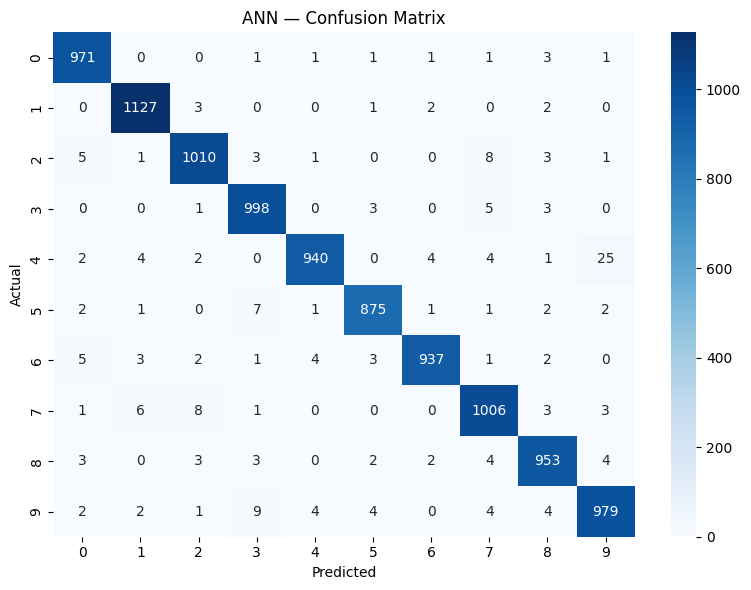


Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.99      0.98      1010
           4       0.99      0.96      0.97       982
           5       0.98      0.98      0.98       892
           6       0.99      0.98      0.98       958
           7       0.97      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.96      0.97      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [13]:
# Confusion Matrix for ANN
from sklearn.metrics import confusion_matrix, classification_report

ann_preds = ann_model.predict(X_test_flat).argmax(axis=1)

cm = confusion_matrix(y_test, ann_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.title('ANN — Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

print("\nClassification Report:")
print(classification_report(y_test, ann_preds))


### Part B — CNN (Convolutional Neural Network)

CNNs are specifically designed for image data, leveraging spatial structure via convolutional filters.


In [14]:
# Reshape for CNN: add channel dimension (28, 28) -> (28, 28, 1)
X_train_cnn = X_train.reshape(-1, 28, 28, 1)
X_val_cnn   = X_val.reshape(-1, 28, 28, 1)
X_test_cnn  = X_test.reshape(-1, 28, 28, 1)

cnn_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
], name="MNIST_CNN")

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()


Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 872,042 (3.33 MB)

 Trainable params: 871,338 (3.32 MB)

 Non-trainable params: 704 (2.75 KB)

In [18]:
# Train CNN with data augmentation
datagen_train = ImageDataGenerator(
    rotation_range=10, width_shift_range=0.1,
    height_shift_range=0.1, zoom_range=0.1
)
datagen_train.fit(X_train_cnn)

early_stop_cnn = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

cnn_history = cnn_model.fit(
    datagen_train.flow(X_train_cnn, y_train_cat, batch_size=128),
    validation_data=(X_val_cnn, y_val_cat),
    epochs=1,
    callbacks=[early_stop_cnn],
    verbose=1
)


422/422 ━━━━━━━━━━━━━━━━━━━━ 162s 382ms/step - accuracy: 0.9883 - loss: 0.0380 - val_accuracy: 0.9913 - val_loss: 0.0276


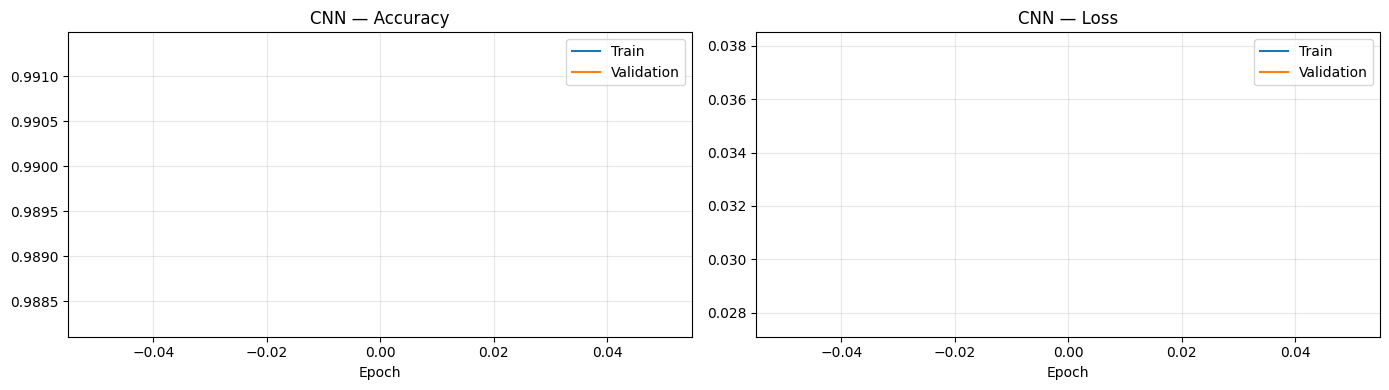

In [24]:
# CNN Training Curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(cnn_history.history['accuracy'], label='Train')
ax1.plot(cnn_history.history['val_accuracy'], label='Validation')
ax1.set_title('CNN — Accuracy'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(cnn_history.history['loss'], label='Train')
ax2.plot(cnn_history.history['val_loss'], label='Validation')
ax2.set_title('CNN — Loss'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()


In [20]:
# Evaluate CNN on test set
cnn_loss, cnn_acc = cnn_model.evaluate(X_test_cnn, y_test_cat, verbose=0)
print(f"CNN Test Accuracy: {cnn_acc*100:.2f}%")
print(f"CNN Test Loss:     {cnn_loss:.4f}")


CNN Test Accuracy: 99.33%
CNN Test Loss:     0.0221


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step


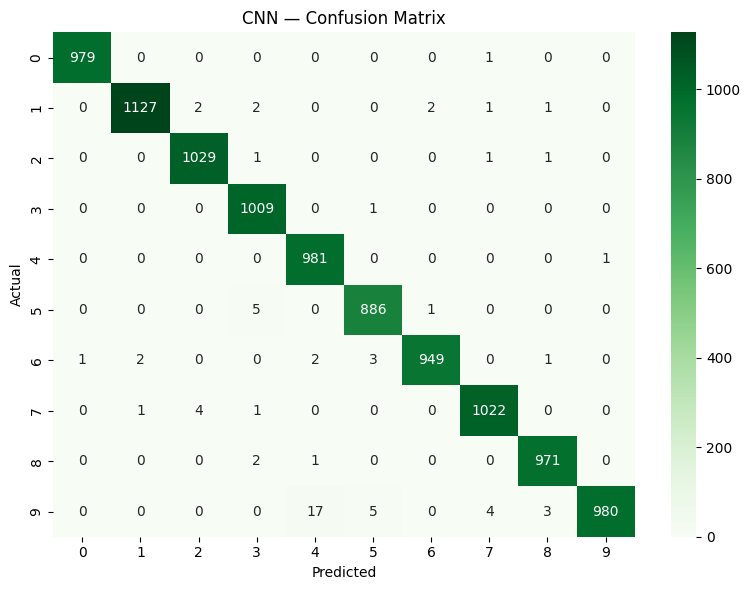


Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       980
           1       1.00      0.99      1.00      1135
           2       0.99      1.00      1.00      1032
           3       0.99      1.00      0.99      1010
           4       0.98      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       1.00      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      1.00      1.00       974
           9       1.00      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [21]:
# Confusion Matrix for CNN
cnn_preds = cnn_model.predict(X_test_cnn).argmax(axis=1)

cm_cnn = confusion_matrix(y_test, cnn_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=range(10), yticklabels=range(10))
plt.title('CNN — Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.tight_layout(); plt.show()

print("\nClassification Report:")
print(classification_report(y_test, cnn_preds))


### Part C — Model Comparison


In [22]:
# Compare ANN vs CNN
print("=" * 50)
print("       MNIST Model Comparison")
print("=" * 50)
print(f"  ANN Test Accuracy:  {ann_acc*100:.2f}%")
print(f"  CNN Test Accuracy:  {cnn_acc*100:.2f}%")
print("=" * 50)
print(f"  CNN improvement:    +{(cnn_acc - ann_acc)*100:.2f}%")
print("=" * 50)


       MNIST Model Comparison
  ANN Test Accuracy:  97.96%
  CNN Test Accuracy:  99.33%
  CNN improvement:    +1.37%


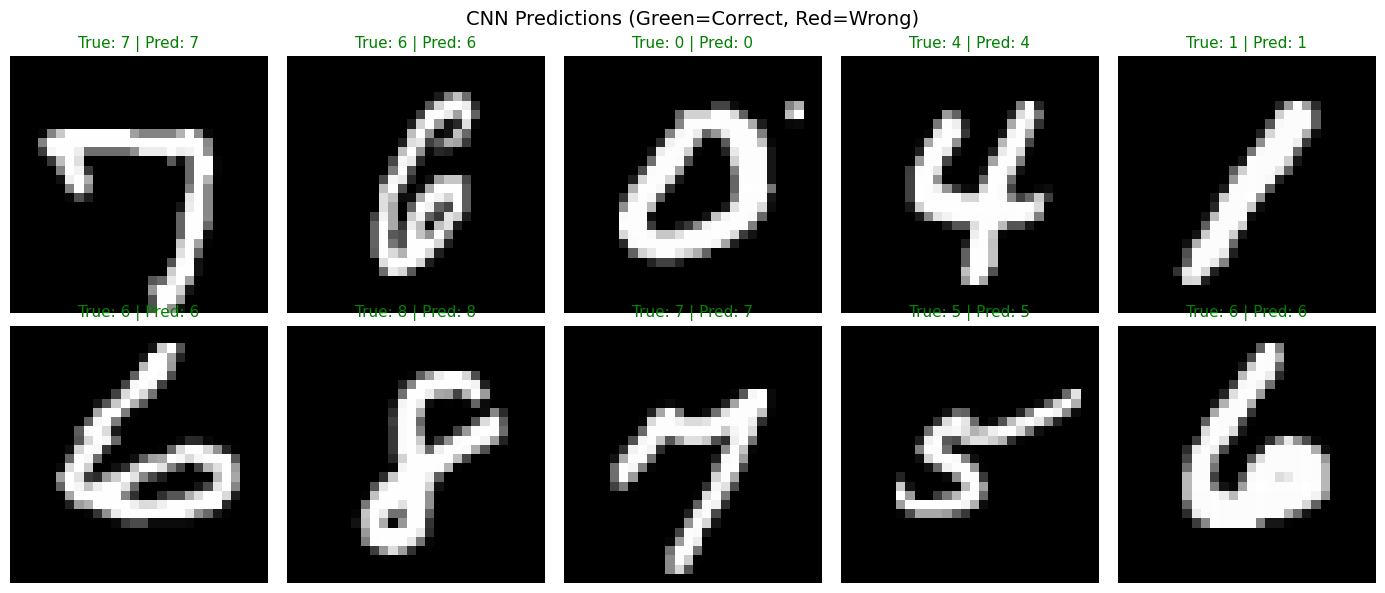

In [23]:
# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
random_idx = np.random.choice(len(X_test), 10, replace=False)
for i, ax in enumerate(axes.flat):
    idx = random_idx[i]
    ax.imshow(X_test[idx], cmap='gray')
    true_label = y_test[idx]
    cnn_pred = cnn_preds[idx]
    color = 'green' if true_label == cnn_pred else 'red'
    ax.set_title(f"True: {true_label} | Pred: {cnn_pred}", color=color, fontsize=11)
    ax.axis('off')
plt.suptitle("CNN Predictions (Green=Correct, Red=Wrong)", fontsize=14)
plt.tight_layout(); plt.show()


## Conclusion

In this notebook, we covered the complete deep learning pipeline:

1. **Perceptron** — the building block of neural networks
2. **Backpropagation from scratch** — understanding gradient computation
3. **ANN from scratch (NumPy)** — building and training without frameworks
4. **Data preprocessing** — normalization, one-hot encoding, augmentation
5. **CNNs** — convolutional layers, pooling, and modern architectures
6. **Transfer Learning** — leveraging pretrained models
7. **MNIST Assignment** — ANN vs CNN comparison for digit recognition

**Key Takeaway:** CNNs significantly outperform fully-connected ANNs on image tasks because they exploit the spatial structure of images through parameter sharing and local connectivity.
